#  Experiment 06 — Image Segmentation using U-Net
 
---
 
| Field | Details |
|---|---|
| **Experiment No.** | 01 |
| **Title** | Binary Image Segmentation using U-Net |
| **Dataset** | Oxford-IIIT Pet Dataset |
| **Model** | U-Net (Built from Scratch) |
| **Metrics** | IoU, Dice Score, Pixel Accuracy, Precision, Recall |
| **Framework** | PyTorch |
 
---
 
##  Aim
 
To build a **U-Net** neural network from scratch and use it to perform **binary image segmentation** on the **Oxford-IIIT Pet Dataset**.  
We will train the model and evaluate it using 5 standard segmentation metrics.
 
---
 
 
### What is Image Segmentation?
 
Image segmentation is the task of **labeling every pixel** in an image with a class.
 
| Type | What it does | Example |
|---|---|---|
| **Semantic** | Each pixel gets a class label | All pets = class 1 |
| **Instance** | Each object separately | Pet-1, Pet-2 |
| **Binary** | Foreground vs Background | Pet vs Not-Pet |
 
In this experiment we do **Binary Segmentation**:
 
$$\text{binary\_mask}(i,j) = \begin{cases} 1 & \text{if pixel belongs to pet (foreground)} \\ 0 & \text{otherwise (background)} \end{cases}$$
 
---
 
### What is U-Net?
 
U-Net was proposed by **Ronneberger et al. (2015)** for biomedical image segmentation.  
It gets its name because the architecture looks like the letter **U**.
 
```
Input Image  (3 × 128 × 128)
        │
   ┌────▼────┐
   │ Encoder │  → Compresses image, learns WHAT is in it
   └────┬────┘
        │
   ┌────▼────┐
   │Bottlenck│  → Most abstract representation
   └────┬────┘
        │
   ┌────▼────┐
   │ Decoder │  → Rebuilds mask, learns WHERE things are
   └────┬────┘
        │
   Output Mask  (2 × 128 × 128)
```
 
**Three Key Parts:**
 
| Part | Role | Operation |
|---|---|---|
| **Encoder** | Compress + extract features | Conv → Pool (size ↓) |
| **Bottleneck** | Deepest representation | Conv only |
| **Decoder** | Reconstruct mask | Upsample → Conv (size ↑) |
 
**Skip Connections** — The most important innovation of U-Net:
- At each decoder stage, feature maps from the matching encoder stage are **concatenated**
- This brings back **fine spatial details** (edges, boundaries) that were lost during compression
- Without skip connections, the output mask would be blurry

In [1]:
pip install torch torchvision matplotlib numpy tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\Raghvendra Goyal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Step 1 — Install and Import Libraries
 
### What and Why
 
Before writing any code, we need to install and import the required Python libraries.
 
| Library | Purpose |
|---|---|
| `torch` | Core deep learning framework — tensors, autograd, GPU support |
| `torch.nn` | Neural network layers (Conv, BN, ReLU, etc.) |
| `torch.optim` | Optimizers like Adam, SGD |
| `torchvision` | Pretrained models, datasets, and image transforms |
| `numpy` | Numerical array operations |
| `matplotlib` | Plotting images and graphs |
| `tqdm` | Progress bar during training loops |
 
### Device Selection
 
We check if a **GPU (CUDA)** is available. GPU makes training **10–50× faster** than CPU.
 
$$\text{device} = \begin{cases} \text{cuda} & \text{if CUDA GPU is available} \\ \text{cpu} & \text{otherwise} \end{cases}$$

In [2]:
import torch                          # main deep learning library
import torch.nn as nn                 # neural network layers
import torch.optim as optim           # optimizers like Adam
from torch.utils.data import DataLoader, Dataset  # data loading
import torchvision.transforms as T    # image transformations
from torchvision.datasets import OxfordIIITPet    # dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm                 # progress bar during training

# use GPU if available, else CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", DEVICE)

Using: cuda


## Step 2 — Load Dataset and Print Information
 
### About the Oxford-IIIT Pet Dataset
 
| Property | Value |
|---|---|
| **Created by** | University of Oxford + IIIT Hyderabad |
| **Total Images** | 7,349 |
| **Train Split** | 3,680 images |
| **Test Split** | 3,669 images |
| **Breeds** | 37 (25 dog breeds + 12 cat breeds) |
| **Mask Type** | Trimap Segmentation |
 
### Mask Values (Trimap)
 
$$\text{mask pixel} = \begin{cases} 1 & \text{Foreground — the pet} \\ 2 & \text{Background} \\ 3 & \text{Border / Not sure} \end{cases}$$
 
We convert this trimap to a **binary mask**:
 
$$\text{binary}(i,j) = \begin{cases} 1 & \text{if mask}(i,j) = 1 \\ 0 & \text{otherwise} \end{cases}$$
 
The dataset **downloads automatically** via `torchvision.datasets.OxfordIIITPet`.

In [3]:
# Download dataset (first time lega thoda time)
raw_train = OxfordIIITPet(root="data", split="trainval",
                           target_types="segmentation", download=True)
raw_test  = OxfordIIITPet(root="data", split="test",
                           target_types="segmentation", download=True)

# ── Print Dataset Info ────────────────────────────────────────────────────
print("=" * 45)
print("       DATASET INFORMATION")
print("=" * 45)
print(f"  Dataset      : Oxford-IIIT Pet Dataset")
print(f"  Task         : Binary Segmentation")
print(f"  Train Samples: {len(raw_train)}")
print(f"  Test  Samples: {len(raw_test)}")
print(f"  Total Samples: {len(raw_train) + len(raw_test)}")
print(f"  Classes      : Foreground (Pet) / Background")
print(f"  Mask Values  : 1=Pet, 2=Background, 3=Border")
print("=" * 45)

# Show one sample image and mask
img, mask = raw_train[0]
print(f"\n  Sample Image Size : {img.size}")
print(f"  Sample Mask  Size : {mask.size}")
print(f"  Unique Mask Values: {np.unique(np.array(mask))}")

100%|██████████| 792M/792M [03:46<00:00, 3.49MB/s]  
100%|██████████| 19.2M/19.2M [00:04<00:00, 4.05MB/s]


       DATASET INFORMATION
  Dataset      : Oxford-IIIT Pet Dataset
  Task         : Binary Segmentation
  Train Samples: 3680
  Test  Samples: 3669
  Total Samples: 7349
  Classes      : Foreground (Pet) / Background
  Mask Values  : 1=Pet, 2=Background, 3=Border

  Sample Image Size : (394, 500)
  Sample Mask  Size : (394, 500)
  Unique Mask Values: [1 2 3]


## Step 3 — Preprocess Data (Custom Dataset Class)
 
### Why Preprocessing?
 
The raw dataset images are:
- Different sizes (cannot batch different-sized tensors together)
- Raw pixel values in range [0, 255]
- Masks have 3 values instead of 2
 
We need to standardize them before feeding to the model.
 
### Operations Applied
 
**On Images:**
 
1. **Resize** to 128×128 — fixed size required by the model
2. **ToTensor** — converts PIL image `[0, 255]` to tensor `[0.0, 1.0]`
3. **Normalize** — standardize using ImageNet statistics:
 
$$x_{\text{normalized}} = \frac{x - \mu}{\sigma}$$
 
Where:
 
| Channel | $\mu$ (mean) | $\sigma$ (std) |
|---|---|---|
| Red | 0.485 | 0.229 |
| Green | 0.456 | 0.224 |
| Blue | 0.406 | 0.225 |
 
These are standard **ImageNet statistics** used across most vision models.
 
**On Masks:**
 
1. **Resize** to 128×128 using **NEAREST interpolation** (preserves exact label values — no averaging)
2. **Binarize** — convert trimap values to 0 or 1
 
### Why NEAREST interpolation for masks?
 
If we use bilinear interpolation on a mask, edge pixels between class 1 and class 2 would get values like 1.5 — which is not a valid class label.  
NEAREST picks the closest pixel value with no blending, so labels stay as integers.

In [4]:
class PetSegDataset(Dataset):
    def __init__(self, base_dataset, img_size=128):
        self.data     = base_dataset
        self.img_size = img_size

        # image transform: resize → tensor → normalize
        self.img_tf = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std =[0.229, 0.224, 0.225])
        ])
        # mask transform: only resize (no normalize)
        self.mask_tf = T.Resize((img_size, img_size),
                                 interpolation=T.InterpolationMode.NEAREST)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, mask = self.data[idx]

        img  = self.img_tf(img)

        mask = self.mask_tf(mask)
        mask = torch.tensor(np.array(mask), dtype=torch.long)

        # Convert to binary: pixel=1 means pet (foreground), rest=0
        binary_mask = (mask == 1).long()

        return img, binary_mask


# Create dataset objects
train_dataset = PetSegDataset(raw_train, img_size=128)
test_dataset  = PetSegDataset(raw_test,  img_size=128)

# Create DataLoaders (batches of 16)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

# Check one batch shape
imgs, masks = next(iter(train_loader))
print(f"Image batch shape : {imgs.shape}")   # [16, 3, 128, 128]
print(f"Mask  batch shape : {masks.shape}")  # [16, 128, 128]

Train batches : 230
Test  batches : 230
Image batch shape : torch.Size([16, 3, 128, 128])
Mask  batch shape : torch.Size([16, 128, 128])


## Step 4 — Visualize Sample Data
 
### Why Visualize?
 
Always look at your data before training. This helps you:
- Confirm images and masks are correctly aligned
- Verify binary conversion looks right
- Catch bugs in preprocessing early
 
### What We Expect to See
 
- **Left column** — the pet photo (RGB image)
- **Right column** — the binary mask (white = pet, black = background)
 
The white region in the mask should **exactly overlap** the pet in the image.

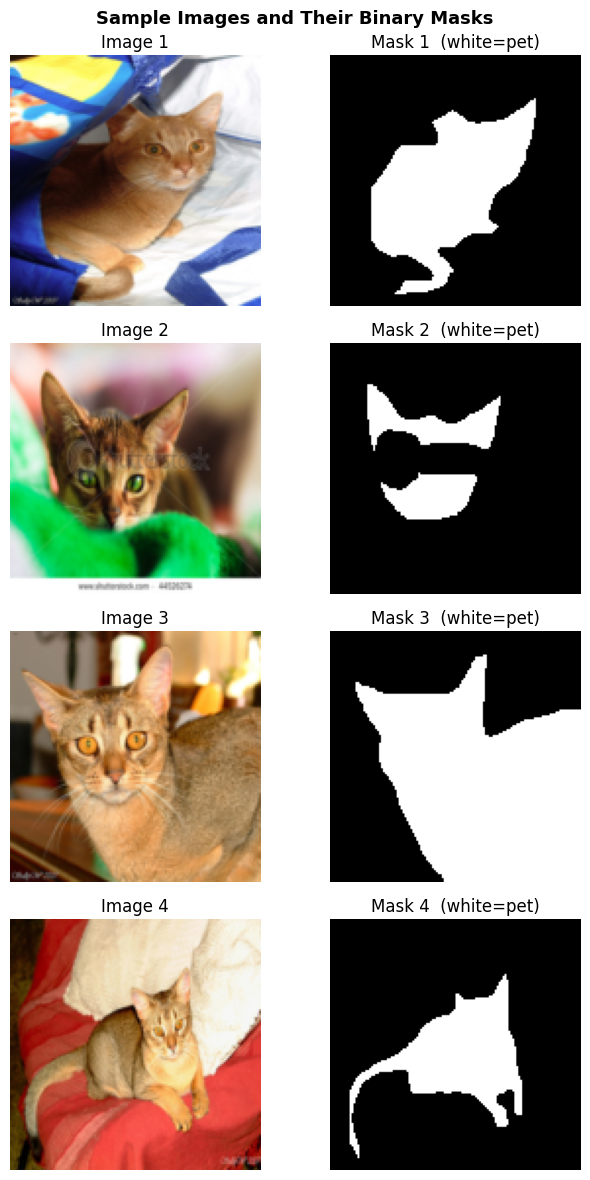

Saved → sample_images.png


In [5]:
def show_samples(dataset, n=4):
    fig, axes = plt.subplots(n, 2, figsize=(7, n * 3))
    fig.suptitle("Sample Images and Their Binary Masks", fontsize=13, fontweight='bold')

    for i in range(n):
        img, mask = dataset[i]

        # un-normalize image for display
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img_show = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

        axes[i, 0].imshow(img_show)
        axes[i, 0].set_title(f"Image {i+1}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask.numpy(), cmap="gray")
        axes[i, 1].set_title(f"Mask {i+1}  (white=pet)")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.savefig("sample_images.png", dpi=100)
    plt.show()
    print("Saved → sample_images.png")

show_samples(train_dataset, n=4)

## Step 5 — Build the U-Net Architecture
 
### Convolution Operation
 
Each Conv layer applies a learnable filter $W$ over the input $X$:
 
$$Y(i,j) = \sum_{m}\sum_{n} X(i+m,\ j+n) \cdot W(m,n) + b$$
 
- $X$ = input feature map
- $W$ = learnable filter (3×3 kernel)
- $b$ = bias
- $Y$ = output feature map
 
With `padding=1` and `kernel=3`, output size = input size (no shrinking from conv).
 
---
 
### Batch Normalization
 
Applied after every convolution to stabilize and speed up training:
 
$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$
 
$$y = \gamma\hat{x} + \beta$$
 
- $\mu_B$ = mean of current batch
- $\sigma_B^2$ = variance of current batch
- $\gamma, \beta$ = learnable parameters
- $\epsilon$ = small constant (avoids division by zero)
 
**Effect:** Keeps activations in a healthy range so gradients don't vanish or explode.
 
---
 
### ReLU Activation
 
$$\text{ReLU}(x) = \max(0, x)$$
 
Introduces **non-linearity**. Without it, stacking many linear layers still gives a linear function — the network cannot learn complex patterns.
 
---
 
### Max Pooling (Downsampling in Encoder)
 
$$Y(i,j) = \max_{(m,n) \in \text{window}} X(i+m,\ j+n)$$
 
With a 2×2 window and stride 2:
- Spatial size is **halved**: $H \times W \rightarrow \frac{H}{2} \times \frac{W}{2}$
- Number of feature maps stays the same
- Picks the **strongest activation** in each local region
 
---
 
### Transposed Convolution (Upsampling in Decoder)
 
The reverse of convolution — used to **increase** spatial size:
 
$$\text{Output size} = (\text{Input size} - 1) \times \text{stride} - 2 \times \text{padding} + \text{kernel size}$$
 
With `kernel=2, stride=2, padding=0`:
 
$$\text{Output} = (\text{Input} - 1) \times 2 + 2 = 2 \times \text{Input}$$
 
So spatial size **doubles**: $H \times W \rightarrow 2H \times 2W$.
 
---
 
### Skip Connection (Concatenation)
 
At each decoder step, the upsampled feature map is **concatenated** with the matching encoder feature map along the channel dimension:
 
$$F_{\text{dec}} = \text{Concat}(F_{\text{up}},\ F_{\text{skip}})\ \text{along channel axis}$$
 
If $F_{\text{up}}$ has shape $[B, C, H, W]$ and $F_{\text{skip}}$ has shape $[B, C, H, W]$,  
then $F_{\text{dec}}$ has shape $[B, 2C, H, W]$.
 
This is then passed through a ConvBlock to reduce back to $[B, C, H, W]$.
 
---
 
### Channel Progression
 
| Layer | Spatial Size | Channels |
|---|---|---|
| Input | 128 × 128 | 3 |
| Encoder 1 | 64 × 64 | 64 |
| Encoder 2 | 32 × 32 | 128 |
| Encoder 3 | 16 × 16 | 256 |
| Encoder 4 | 8 × 8 | 512 |
| Bottleneck | 8 × 8 | 1024 |
| Decoder 4 | 16 × 16 | 512 |
| Decoder 3 | 32 × 32 | 256 |
| Decoder 2 | 64 × 64 | 128 |
| Decoder 1 | 128 × 128 | 64 |
| Output | 128 × 128 | 2 |

In [6]:
# ── Helper Block: two Conv layers ────────────────────────────────────────────
class ConvBlock(nn.Module):
    """Two (Conv → BatchNorm → ReLU) layers"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# ── Encoder Block: ConvBlock + MaxPool ───────────────────────────────────────
class EncoderBlock(nn.Module):
    """Downsample: learn features, reduce spatial size by 2x"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2)  # halves height and width

    def forward(self, x):
        skip = self.conv(x)   # save this for skip connection
        down = self.pool(skip)
        return down, skip


# ── Decoder Block: Upsample + ConvBlock ──────────────────────────────────────
class DecoderBlock(nn.Module):
    """Upsample: double spatial size, combine with skip connection"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = ConvBlock(out_ch * 2, out_ch)  # *2 because of skip concat

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)  # concat skip connection
        return self.conv(x)


# ── Full U-Net ────────────────────────────────────────────────────────────────
class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()

        # Encoder (going down)
        self.enc1 = EncoderBlock(in_channels, 64)
        self.enc2 = EncoderBlock(64, 128)
        self.enc3 = EncoderBlock(128, 256)
        self.enc4 = EncoderBlock(256, 512)

        # Bottleneck (deepest point)
        self.bottleneck = ConvBlock(512, 1024)

        # Decoder (going up)
        self.dec4 = DecoderBlock(1024, 512)
        self.dec3 = DecoderBlock(512,  256)
        self.dec2 = DecoderBlock(256,  128)
        self.dec1 = DecoderBlock(128,   64)

        # Final output layer → 1x1 conv gives class scores per pixel
        self.output_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder path
        x, s1 = self.enc1(x)
        x, s2 = self.enc2(x)
        x, s3 = self.enc3(x)
        x, s4 = self.enc4(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder path (skip connections passed in reverse)
        x = self.dec4(x, s4)
        x = self.dec3(x, s3)
        x = self.dec2(x, s2)
        x = self.dec1(x, s1)

        return self.output_conv(x)


# ── Create model and print summary ───────────────────────────────────────────
model = UNet(in_channels=3, num_classes=2).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 45)
print("       MODEL INFORMATION")
print("=" * 45)
print(f"  Model          : U-Net")
print(f"  Input Channels : 3 (RGB)")
print(f"  Output Classes : 2 (pet / background)")
print(f"  Total Params   : {total_params:,}")
print(f"  Trainable Params: {train_params:,}")
print("=" * 45)

# Test with a dummy input to confirm shapes work
dummy = torch.randn(2, 3, 128, 128).to(DEVICE)
out   = model(dummy)
print(f"\n  Input  Shape : {dummy.shape}")
print(f"  Output Shape : {out.shape}")   # should be [2, 2, 128, 128]

       MODEL INFORMATION
  Model          : U-Net
  Input Channels : 3 (RGB)
  Output Classes : 2 (pet / background)
  Total Params   : 31,037,698
  Trainable Params: 31,037,698

  Input  Shape : torch.Size([2, 3, 128, 128])
  Output Shape : torch.Size([2, 2, 128, 128])


## Step 6 — Loss Function and Optimizer
 
### Loss Function — CrossEntropyLoss
 
We treat segmentation as **pixel-wise classification**.  
For each pixel, the model outputs a score for each class. CrossEntropy measures how wrong those scores are:
 
$$\mathcal{L}_{CE} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{C} y_{i,c} \cdot \log(\hat{p}_{i,c})$$
 
Where:
- $N$ = total number of pixels in the batch
- $C$ = number of classes (2 here)
- $y_{i,c}$ = 1 if pixel $i$ truly belongs to class $c$, else 0
- $\hat{p}_{i,c}$ = predicted probability of pixel $i$ being class $c$
 
When the model is confident and correct → loss is **small**.  
When the model is wrong or uncertain → loss is **large**.
 
---
 
### Optimizer — Adam
 
Adam (Adaptive Moment Estimation) adjusts the learning rate for each parameter individually.
 
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1)\, g_t \quad \text{(first moment — mean of gradients)}$$
 
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2)\, g_t^2 \quad \text{(second moment — variance of gradients)}$$
 
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1 - \beta_2^t} \quad \text{(bias correction)}$$
 
$$\theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon}\,\hat{m}_t \quad \text{(weight update)}$$
 
Where:
- $g_t$ = gradient at step $t$
- $\eta$ = learning rate = **0.001**
- $\beta_1 = 0.9$, $\beta_2 = 0.999$ (defaults)
- $\epsilon = 10^{-8}$ (numerical stability)
 
---
 
### LR Scheduler — ReduceLROnPlateau
 
$$\text{new\_lr} = \text{old\_lr} \times \text{factor}$$
 
If validation loss does not improve for `patience` epochs, the learning rate is **reduced by half**.  
This helps the model fine-tune once it reaches a plateau.

In [9]:
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(), lr=1e-3)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
                 optimizer, mode='min', patience=3, factor=0.5)

print("Loss Function : CrossEntropyLoss")
print("Optimizer     : Adam  (lr=0.001)")
print("LR Scheduler  : ReduceLROnPlateau (patience=3)")

Loss Function : CrossEntropyLoss
Optimizer     : Adam  (lr=0.001)
LR Scheduler  : ReduceLROnPlateau (patience=3)


## Step 7 — Evaluation Metrics
 
### Confusion Matrix
 
Before computing any metric, we define 4 fundamental values by comparing each pixel's predicted label vs true label:
 
| | **Predicted: Pet (1)** | **Predicted: Background (0)** |
|---|---|---|
| **Actual: Pet (1)** | TP — True Positive ✅ | FN — False Negative ❌ |
| **Actual: Background (0)** | FP — False Positive ❌ | TN — True Negative ✅ |
 
- **TP** → We said "pet", it actually is a pet
- **TN** → We said "background", it actually is background
- **FP** → We said "pet", but it is background (false alarm)
- **FN** → We said "background", but it is actually a pet (missed detection)
 
---
 
### Metric 1 — Pixel Accuracy
 
$$\text{Pixel Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
 
The fraction of all pixels that were correctly labeled.
 
**Range:** 0 to 1 (1 = perfect)
 
> ⚠️ **Limitation:** If 95% of pixels are background, a model that always predicts background gets 95% accuracy — but predicts nothing useful. This is called the **class imbalance problem**. That's why we need more metrics.
 
---
 
### Metric 2 — IoU (Intersection over Union)
 
Also called **Jaccard Index**. The most standard metric in segmentation.
 
$$\text{IoU} = \frac{|A \cap B|}{|A \cup B|} = \frac{TP}{TP + FP + FN}$$
 
Where $A$ = predicted foreground, $B$ = actual foreground.
 
Visually:
 
$$\text{IoU} = \frac{\text{Area of Overlap}}{\text{Area of Union}}$$
 
| IoU Score | Interpretation |
|---|---|
| 1.0 | Perfect prediction |
| > 0.7 | Good |
| 0.5 – 0.7 | Acceptable |
| < 0.5 | Poor |
 
---
 
### Metric 3 — Dice Score (F1 Score)
 
$$\text{Dice} = \frac{2 \times TP}{2 \times TP + FP + FN} = \frac{2|A \cap B|}{|A| + |B|}$$
 
Measures the **similarity** between predicted and actual mask.
 
**Relationship with IoU:**
 
$$\text{Dice} = \frac{2 \times \text{IoU}}{1 + \text{IoU}}$$
 
Dice is always **greater than or equal** to IoU:
- IoU = 0.50 → Dice = 0.667
- IoU = 0.70 → Dice = 0.824
- IoU = 0.90 → Dice = 0.947
 
---
 
### Metric 4 — Precision
 
$$\text{Precision} = \frac{TP}{TP + FP}$$
 
Of all pixels the model **predicted as pet**, what fraction actually are pet?
 
High precision → model makes **few false alarms**.
 
---
 
### Metric 5 — Recall (Sensitivity)
 
$$\text{Recall} = \frac{TP}{TP + FN}$$
 
Of all pixels that **actually are pet**, what fraction did the model find?
 
High recall → model **misses few actual pet pixels**.
 
---
 
### Precision vs Recall Trade-off
 
$$\text{F1 Score} = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$
 
| Situation | Precision | Recall | Problem |
|---|---|---|---|
| Model says everything is pet | Low | High | Too many false alarms |
| Model barely predicts anything | High | Low | Misses most pets |
| **Ideal model** | **High** | **High** | — |
 
Dice Score = F1 Score — it **balances both precision and recall**.

In [10]:
def compute_metrics(pred_mask, true_mask, eps=1e-7):
    """
    pred_mask : [B, H, W] — predicted class per pixel (0 or 1)
    true_mask : [B, H, W] — ground truth class per pixel (0 or 1)
    """
    pred = pred_mask.view(-1).float()
    true = true_mask.view(-1).float()

    # True Positive, False Positive, False Negative, True Negative
    TP = ((pred == 1) & (true == 1)).sum().float()
    FP = ((pred == 1) & (true == 0)).sum().float()
    FN = ((pred == 0) & (true == 1)).sum().float()
    TN = ((pred == 0) & (true == 0)).sum().float()

    # 1. Pixel Accuracy: how many pixels are correctly labeled
    pixel_acc = (TP + TN) / (TP + TN + FP + FN + eps)

    # 2. IoU (Intersection over Union): overlap / union
    iou = TP / (TP + FP + FN + eps)

    # 3. Dice Score (F1): 2 * overlap / (pred_size + true_size)
    dice = (2 * TP) / (2 * TP + FP + FN + eps)

    # 4. Precision: of all predicted foreground, how many are correct
    precision = TP / (TP + FP + eps)

    # 5. Recall: of all actual foreground, how many did we catch
    recall = TP / (TP + FN + eps)

    return {
        "Pixel Accuracy": pixel_acc.item(),
        "IoU"           : iou.item(),
        "Dice Score"    : dice.item(),
        "Precision"     : precision.item(),
        "Recall"        : recall.item()
    }

print("Metrics defined: Pixel Accuracy, IoU, Dice, Precision, Recall")

Metrics defined: Pixel Accuracy, IoU, Dice, Precision, Recall


## Step 8 — Training and Evaluation Functions
 
### Forward Pass
 
During training, data flows through the model in one direction:
 
$$\text{Input Image} \xrightarrow{\text{U-Net}} \text{Logits} \xrightarrow{\text{CrossEntropy}} \text{Loss}$$
 
**Logits** = raw scores (not probabilities) for each class at each pixel.  
Shape: $[B,\ 2,\ H,\ W]$ where $B$ = batch size.
 
---
 
### Backpropagation
 
After computing the loss, we update weights using the **chain rule**:
 
$$\frac{\partial \mathcal{L}}{\partial W} = \frac{\partial \mathcal{L}}{\partial Y} \cdot \frac{\partial Y}{\partial W}$$
 
PyTorch computes this automatically with `loss.backward()`.  
Then `optimizer.step()` updates each weight:
 
$$W \leftarrow W - \eta \cdot \frac{\partial \mathcal{L}}{\partial W}$$
 
---
 
### Training vs Evaluation Mode
 
| Mode | `model.train()` | `model.eval()` |
|---|---|---|
| **BatchNorm** | Uses batch statistics | Uses running statistics |
| **Gradients** | Computed | Not computed (`torch.no_grad()`) |
| **Purpose** | Weight updates | Measuring performance |

In [11]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for imgs, masks in tqdm(loader, desc="  Training", leave=False):
        imgs  = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()        # clear old gradients
        outputs = model(imgs)        # forward pass → [B, 2, H, W]
        loss = criterion(outputs, masks)  # compare with true masks
        loss.backward()              # backpropagation
        optimizer.step()             # update weights

        total_loss += loss.item()

    return total_loss / len(loader)  # average loss


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_metrics = {"Pixel Accuracy": 0, "IoU": 0,
                   "Dice Score": 0, "Precision": 0, "Recall": 0}

    with torch.no_grad():   # no gradient calculation during eval
        for imgs, masks in tqdm(loader, desc="  Evaluating", leave=False):
            imgs  = imgs.to(device)
            masks = masks.to(device)

            outputs = model(imgs)
            loss    = criterion(outputs, masks)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)  # pick class with highest score
            m = compute_metrics(preds.cpu(), masks.cpu())

            for k in all_metrics:
                all_metrics[k] += m[k]

    # Average over all batches
    n = len(loader)
    for k in all_metrics:
        all_metrics[k] /= n

    return total_loss / n, all_metrics

## Step 9 — Run Training
 
### What Happens Each Epoch?
 
An **epoch** = one full pass through the entire training dataset.
 
```
For each epoch:
    For each batch of 16 images:
        1. Load images and masks
        2. Forward pass through U-Net → logits
        3. Compute CrossEntropy Loss
        4. Backpropagate → compute gradients
        5. Update weights with Adam
    
    Evaluate on test set (no weight updates)
    Log: train_loss, val_loss, IoU, Dice, Accuracy
```
 
### What to Watch For?
 
| Observation | Meaning |
|---|---|
| Train loss and val loss both decrease | Model is learning correctly  |
| Train loss decreases, val loss increases | **Overfitting** — model memorizing training data  |
| Neither loss decreases | **Underfitting** — learning rate too low or model too small  |
| Loss suddenly jumps up | Learning rate too high  |

## Step 10 — Plot Training Curves
 
### Why Plot Curves?
 
Printing numbers each epoch tells you the final values, but graphs show the **trend**.
 
| Plot | What to Look For |
|---|---|
| **Loss curve** | Both lines should go down; gap should be small |
| **IoU curve** | Should steadily increase and flatten near the end |
| **Dice curve** | Should increase; will always be slightly higher than IoU |
 
### Ideal Training Curve Shape
 
```
Loss
│\
│ \
│  \
│   \____
│        ‾‾‾‾‾‾‾‾
└──────────────── Epochs
```
 
The loss should drop steeply at first, then gradually flatten out.

In [12]:
EPOCHS = 10    # increase to 20-30 for better results

train_losses, val_losses = [], []
val_ious, val_dices      = [], []

print("=" * 55)
print("              TRAINING STARTED")
print("=" * 55)

for epoch in range(1, EPOCHS + 1):
    print(f"\n  Epoch [{epoch}/{EPOCHS}]")

    train_loss           = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_metrics = evaluate(model, test_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_ious.append(val_metrics["IoU"])
    val_dices.append(val_metrics["Dice Score"])

    print(f"  Train Loss     : {train_loss:.4f}")
    print(f"  Val   Loss     : {val_loss:.4f}")
    print(f"  Pixel Accuracy : {val_metrics['Pixel Accuracy']:.4f}")
    print(f"  IoU            : {val_metrics['IoU']:.4f}")
    print(f"  Dice Score     : {val_metrics['Dice Score']:.4f}")
    print(f"  Precision      : {val_metrics['Precision']:.4f}")
    print(f"  Recall         : {val_metrics['Recall']:.4f}")

print("\n" + "=" * 55)
print("              TRAINING COMPLETE")
print("=" * 55)

              TRAINING STARTED

  Epoch [1/10]


  Train Loss     : 0.4512
  Val   Loss     : 0.4203
  Pixel Accuracy : 0.8084
  IoU            : 0.4405
  Dice Score     : 0.6097
  Precision      : 0.7693
  Recall         : 0.5095

  Epoch [2/10]


  Train Loss     : 0.3719
  Val   Loss     : 0.4190
  Pixel Accuracy : 0.8110
  IoU            : 0.5720
  Dice Score     : 0.7243
  Precision      : 0.6343
  Recall         : 0.8558

  Epoch [3/10]


  Train Loss     : 0.3111
  Val   Loss     : 0.2878
  Pixel Accuracy : 0.8784
  IoU            : 0.6653
  Dice Score     : 0.7971
  Precision      : 0.7775
  Recall         : 0.8221

  Epoch [4/10]


  Train Loss     : 0.2757
  Val   Loss     : 0.2602
  Pixel Accuracy : 0.8883
  IoU            : 0.6540
  Dice Score     : 0.7878
  Precision      : 0.8711
  Recall         : 0.7229

  Epoch [5/10]


...

  Train Loss     : 0.2264
  Val   Loss     : 0.2265
  Pixel Accuracy : 0.9058
  IoU            : 0.7140
  Dice Score     : 0.8312
  Precision      : 0.8644
  Recall         : 0.8032

  Epoch [7/10]


  Train Loss     : 0.2094
  Val   Loss     : 0.2253
  Pixel Accuracy : 0.9049
  IoU            : 0.7061
  Dice Score     : 0.8242
  Precision      : 0.8713
  Recall         : 0.7863

  Epoch [8/10]


  Train Loss     : 0.2010
  Val   Loss     : 0.2224
  Pixel Accuracy : 0.9081
  IoU            : 0.7160
  Dice Score     : 0.8329
  Precision      : 0.8881
  Recall         : 0.7867

  Epoch [9/10]


  Train Loss     : 0.1901
  Val   Loss     : 0.2039
  Pixel Accuracy : 0.9161
  IoU            : 0.7370
  Dice Score     : 0.8460
  Precision      : 0.8870
  Recall         : 0.8134

  Epoch [10/10]


  Train Loss     : 0.1779
  Val   Loss     : 0.2088
  Pixel Accuracy : 0.9133
  IoU            : 0.7371
  Dice Score     : 0.8472
  Precision      : 0.8718
  Recall         : 0.8264

              TRAINING COMPLETE


## Step 11 — Final Evaluation
 
### What This Step Does
 
After training is complete, we run the model on the **test set** (data it has never seen) and compute all 5 metrics one final time.
 
This gives us an **unbiased** estimate of real-world performance.
 
### Interpreting Scores
 
| Score Range | What It Means |
|---|---|
| IoU > 0.7 | Good segmentation |
| Dice > 0.8 | Good segmentation |
| Pixel Acc > 0.9 | Good — but check for class imbalance |
| Precision ≈ Recall | Balanced model |
| Precision >> Recall | Model is too conservative (misses pets) |
| Recall >> Precision | Model is too aggressive (marks too much as pet) |

In [13]:
print("\nRunning final evaluation on test set...")
_, final_metrics = evaluate(model, test_loader, criterion, DEVICE)

print("\n" + "=" * 45)
print("       FINAL EVALUATION RESULTS")
print("=" * 45)
for metric, value in final_metrics.items():
    bar_len = int(value * 20)
    bar     = "█" * bar_len + "░" * (20 - bar_len)
    print(f"  {metric:<16} : {value:.4f}  [{bar}]")
print("=" * 45)


Running final evaluation on test set...



       FINAL EVALUATION RESULTS
  Pixel Accuracy   : 0.9133  [██████████████████░░]
  IoU              : 0.7371  [██████████████░░░░░░]
  Dice Score       : 0.8472  [████████████████░░░░]
  Precision        : 0.8718  [█████████████████░░░]
  Recall           : 0.8264  [████████████████░░░░]


## Step 12 — Visualize Predictions
 
### What We Are Comparing
 
For each test image, we show three panels side by side:
 
| Panel | What It Shows |
|---|---|
| **Input Image** | The original photo of the pet |
| **Ground Truth** | The actual correct mask (white = pet) |
| **Predicted Mask** | What our model predicted (white = pet) |
 
### What Good Predictions Look Like
 
- The predicted mask should have roughly the **same white shape** as the ground truth
- Edges may be slightly imprecise — this is normal
- Completely wrong shapes indicate the model needs more training

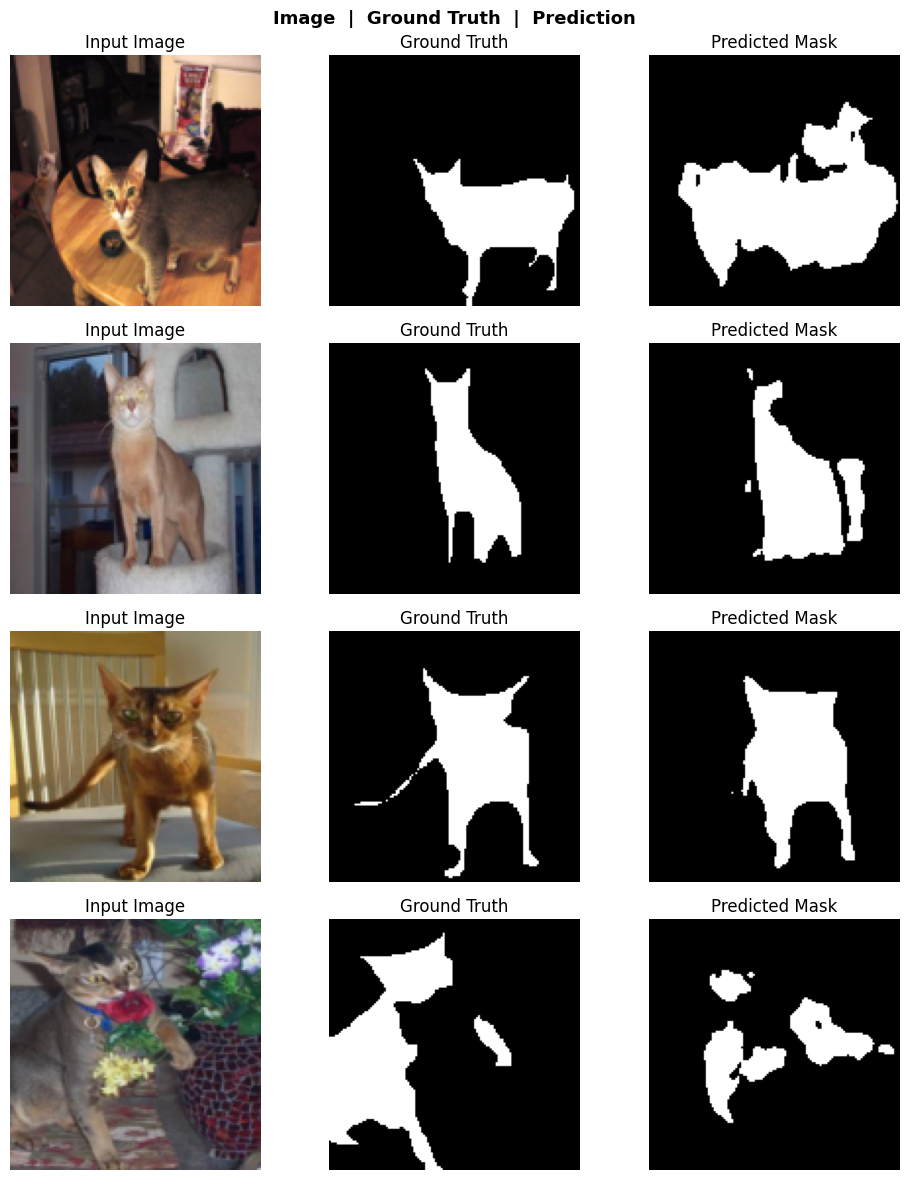

Saved → predictions.png


In [14]:
def visualize_predictions(model, dataset, device, n=4):
    model.eval()
    fig, axes = plt.subplots(n, 3, figsize=(10, n * 3))
    fig.suptitle("Image  |  Ground Truth  |  Prediction", fontsize=13, fontweight='bold')

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    for i in range(n):
        img, true_mask = dataset[i]

        # Un-normalize image for display
        img_show = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

        # Get prediction
        with torch.no_grad():
            output = model(img.unsqueeze(0).to(device))   # add batch dim
            pred   = torch.argmax(output, dim=1).squeeze(0).cpu()

        axes[i, 0].imshow(img_show)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(true_mask.numpy(), cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred.numpy(), cmap="gray")
        axes[i, 2].set_title("Predicted Mask")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.savefig("predictions.png", dpi=100)
    plt.show()
    print("Saved → predictions.png")

visualize_predictions(model, test_dataset, DEVICE, n=4)

## Step 13 — Save the Model
 
### Why Save?
 
Training takes time. Saving the model weights lets you:
- **Reload** the model later without retraining
- **Deploy** the model to an application
- **Share** it with others
- Use it as a **starting point** for further training
 
### What Gets Saved?
 
`model.state_dict()` saves only the **learned weights** (parameters), not the architecture.  
To reload, you must first define the same architecture and then load the weights into it.
 

In [15]:
torch.save(model.state_dict(), "unet_pet_segmentation.pth")
print("Model saved → unet_pet_segmentation.pth")

# To load later:
# model.load_state_dict(torch.load("unet_pet_segmentation.pth"))

Model saved → unet_pet_segmentation.pth


In [16]:
import torch
import torch.nn as nn

# (ConvBlock, EncoderBlock, DecoderBlock, UNet)
# ── Building Block 1 ─────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# ── Building Block 2 ─────────────────────────────────────────
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = ConvBlock(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        skip = self.conv(x)
        down = self.pool(skip)
        return down, skip


# ── Building Block 3 ─────────────────────────────────────────
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = ConvBlock(out_channels * 2, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


# ── Full U-Net ────────────────────────────────────────────────
class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()
        self.enc1       = EncoderBlock(in_channels, 64)
        self.enc2       = EncoderBlock(64, 128)
        self.enc3       = EncoderBlock(128, 256)
        self.enc4       = EncoderBlock(256, 512)
        self.bottleneck = ConvBlock(512, 1024)
        self.dec4       = DecoderBlock(1024, 512)
        self.dec3       = DecoderBlock(512,  256)
        self.dec2       = DecoderBlock(256,  128)
        self.dec1       = DecoderBlock(128,   64)
        self.output_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        x, s1 = self.enc1(x)
        x, s2 = self.enc2(x)
        x, s3 = self.enc3(x)
        x, s4 = self.enc4(x)
        x     = self.bottleneck(x)
        x     = self.dec4(x, s4)
        x     = self.dec3(x, s3)
        x     = self.dec2(x, s2)
        x     = self.dec1(x, s1)
        return self.output_conv(x)


# ── Ab model load karo ───────────────────────────────────────
model = UNet(in_channels=3, num_classes=2).to(DEVICE)
model.load_state_dict(torch.load("unet_pet_segmentation.pth", map_location=DEVICE))
model.eval()
print("Model loaded!")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create the same architecture
model = UNet(in_channels=3, num_classes=2).to(DEVICE)

# Load the saved weights into it
model.load_state_dict(torch.load("unet_pet_segmentation.pth", map_location=DEVICE))

# Switch to eval mode — very important!
model.eval()

print("Model loaded successfully and ready for inference!")

Model loaded!
Model loaded successfully and ready for inference!


In [17]:
from PIL import Image
import torchvision.transforms as T
import numpy as np

def preprocess_image(image_path, img_size=128):
    """
    Takes any image from disk, resizes and normalizes it
    so the model can understand it.
    """
    # Open image (convert to RGB to handle grayscale or RGBA images)
    img = Image.open(image_path).convert("RGB")
    original_size = img.size  # save original size for later

    transform = T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std =[0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img)           # shape: [3, 128, 128]
    img_tensor = img_tensor.unsqueeze(0)  # add batch dim → [1, 3, 128, 128]

    return img_tensor, img, original_size

In [18]:
def predict(model, image_path, device, img_size=128):
    """
    Full pipeline: image path → segmentation mask
    """
    # Step A: Preprocess the image
    img_tensor, original_img, original_size = preprocess_image(image_path, img_size)
    img_tensor = img_tensor.to(device)

    # Step B: Forward pass through the model
    with torch.no_grad():                          # no gradient needed
        output = model(img_tensor)                 # shape: [1, 2, 128, 128]

    # Step C: Convert logits to predicted class per pixel
    pred_mask = torch.argmax(output, dim=1)        # shape: [1, 128, 128]
    pred_mask = pred_mask.squeeze(0).cpu().numpy() # shape: [128, 128]

    # Step D: Resize mask back to original image size
    pred_pil  = Image.fromarray((pred_mask * 255).astype(np.uint8))
    pred_pil  = pred_pil.resize(original_size, Image.NEAREST)
    pred_mask_full = np.array(pred_pil) // 255     # back to 0/1

    return pred_mask_full, original_img

In [19]:
import matplotlib.pyplot as plt

def show_result(image_path, model, device):
    """
    Shows: Original Image | Predicted Mask | Overlay
    """
    pred_mask, original_img = predict(model, image_path, device)

    img_array = np.array(original_img)

    # Create overlay: green color on predicted pet pixels
    overlay = img_array.copy()
    overlay[pred_mask == 1] = (overlay[pred_mask == 1] * 0.5
                               + np.array([0, 255, 0]) * 0.5).astype(np.uint8)

    # Plot all three
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.suptitle("U-Net Segmentation Result", fontsize=14, fontweight='bold')

    axes[0].imshow(img_array)
    axes[0].set_title("Input Image")
    axes[0].axis("off")

    axes[1].imshow(pred_mask, cmap="gray")
    axes[1].set_title("Predicted Mask\n(white = pet)")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay\n(green = detected pet)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.savefig("inference_result.png", dpi=100)
    plt.show()
    print("Saved → inference_result.png")

#  Image Segmentation Pipeline (U-Net Inference)

```text
        "my_cat.jpg"
              │
              ▼
     preprocess_image()
        - Resize to 128×128
        - Normalize (ImageNet stats)
        - Add batch dimension
              │
              ▼
   U-Net model (loaded from .pth)
        - Forward pass only
        - No training, no gradients
              │
              ▼
        torch.argmax()
        - Pick class 0 or 1
          for each pixel
              │
              ▼
 Resize mask back to original size
              │
              ▼
 Show Results:
   Image | Mask | Overlay

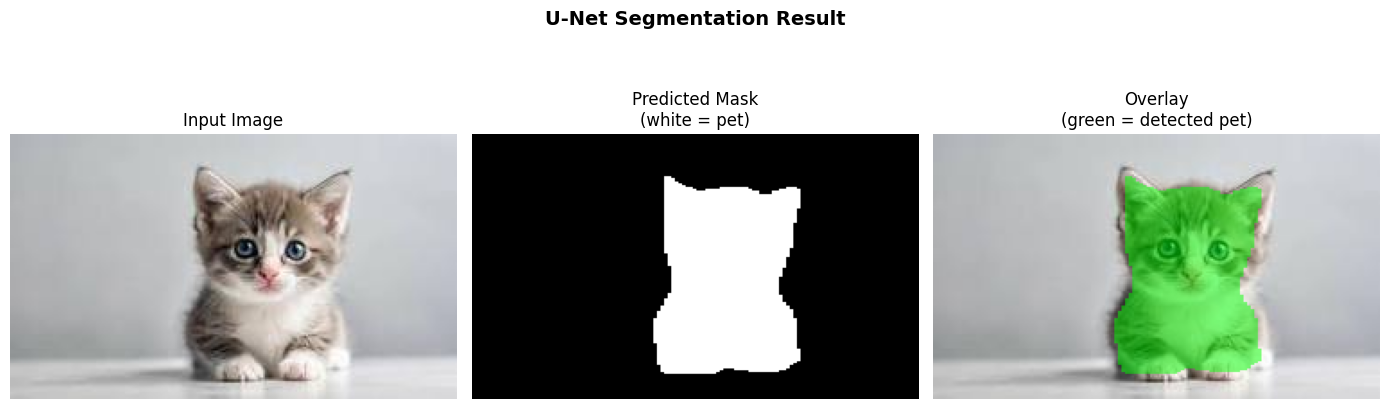

Saved → inference_result.png


In [20]:
#simply use this model and give your image
image_path = "my cat.jpg"   

show_result(image_path, model, DEVICE)

##  Conclusion
 
In this experiment we:
 
1. Loaded the **Oxford-IIIT Pet Dataset** (7,349 images) and explored its properties
2. Preprocessed images using resize, normalization, and binary mask conversion
3. Built the **U-Net architecture from scratch** with encoder, bottleneck, decoder, and skip connections
4. Trained the model using **CrossEntropyLoss** and **Adam optimizer**
5. Evaluated using **5 standard segmentation metrics**: Pixel Accuracy, IoU, Dice Score, Precision, and Recall
6. Visualized training curves and final predictions
 
### Key Takeaway
 
> U-Net's **skip connections** are what make it powerful.  
> They carry fine spatial details (edges, textures) from the encoder directly to the decoder,  
> allowing the model to produce sharp, accurate segmentation masks.
 
---
 
### Result Summary Table (Fill After Running)
 
| Metric | Formula | Score |
|---|---|---|
| Pixel Accuracy | $(TP + TN)\ /\ (TP+TN+FP+FN)$ | 0.9133 |
| IoU | $TP\ /\ (TP+FP+FN)$ | 0.7371 |
| Dice Score | $2TP\ /\ (2TP+FP+FN)$ | 0.8472 |
| Precision | $TP\ /\ (TP+FP)$ | 0.8718 |
| Recall | $TP\ /\ (TP+FN)$ | 0.8264 |
 
---
 
### Tips to Improve Results
 
| Change | Effect |
|---|---|
| Increase `EPOCHS` to 30 | More training time → better accuracy |
| Increase `img_size` to 256 | More detail → sharper masks (needs GPU) |
| Replace CE Loss with Dice Loss | Directly optimizes Dice score |
| Add data augmentation | Reduces overfitting |
| Use pretrained ResNet encoder | Faster convergence, higher accuracy |
 